In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree, DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [32]:
df =pd.read_excel("Online Retail.xlsx")

print(df.head())
print(df.info())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       -----------

In [33]:
df=df.dropna(subset=["CustomerID"])

In [34]:
df=df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [35]:
df=df[df["Quantity"]>0]
df=df[df["UnitPrice"]>0]

In [37]:
df["TotalAmount"]=df["Quantity"]*df["UnitPrice"]

In [38]:
print(df.shape)
print(df.head())

(397884, 9)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalAmount  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom        15.30  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom        22.00  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  


In [39]:
customer_data = df.groupby("CustomerID").agg(
    TotalSpend=("TotalAmount", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfTransactions=("InvoiceNo", "nunique"),
    NumberOfProducts=("StockCode", "nunique"),
    AverageOrderValue=("TotalAmount", "mean"),
    Country=("Country", "first")
).reset_index()

print(customer_data.head())


   CustomerID  TotalSpend  TotalQuantity  NumberOfTransactions  \
0     12346.0    77183.60          74215                     1   
1     12347.0     4310.00           2458                     7   
2     12348.0     1797.24           2341                     4   
3     12349.0     1757.55            631                     1   
4     12350.0      334.40            197                     1   

   NumberOfProducts  AverageOrderValue         Country  
0                 1       77183.600000  United Kingdom  
1               103          23.681319         Iceland  
2                22          57.975484         Finland  
3                73          24.076027           Italy  
4                17          19.670588          Norway  


In [41]:
customer_data["Segment"] =pd.qcut(
    customer_data["TotalSpend"],
    q=3,
    labels=["Low Value","Medium Value","High Value"]
)
print(customer_data["Segment"].value_counts())
        

Segment
Low Value       1446
Medium Value    1446
High Value      1446
Name: count, dtype: int64


In [43]:
features=[
    "TotalQuantity",
    "NumberOfTransactions",
    "NumberOfProducts",
    "AverageOrderValue"
]
x=customer_data[features]
y=customer_data["Segment"]

In [44]:
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [47]:
id3_model=DecisionTreeClassifier(
    criterion="entropy",
    random_state=42,
    max_depth=4
)
id3_model.fit(x_train,y_train)
y_pred=id3_model.predict(x_test)

print("Predictions: ")
print(y_pred[:20])


Predictions: 
['Low Value' 'Low Value' 'Low Value' 'Low Value' 'Medium Value'
 'Low Value' 'Low Value' 'High Value' 'Low Value' 'Medium Value'
 'Low Value' 'Medium Value' 'High Value' 'High Value' 'High Value'
 'High Value' 'Low Value' 'Low Value' 'High Value' 'Low Value']


In [48]:
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy: ", accuracy)
print("\nclassification Report: ")
print(classification_report(y_test,y_pred))

Accuracy:  0.8467741935483871

classification Report: 
              precision    recall  f1-score   support

  High Value       0.93      0.87      0.90       289
   Low Value       0.87      0.85      0.86       289
Medium Value       0.75      0.82      0.78       290

    accuracy                           0.85       868
   macro avg       0.85      0.85      0.85       868
weighted avg       0.85      0.85      0.85       868



In [49]:
print("\nConfusion Matrics: ")
print(confusion_matrix(y_test,y_pred))



Confusion Matrics: 
[[251   2  36]
 [  0 247  42]
 [ 19  34 237]]


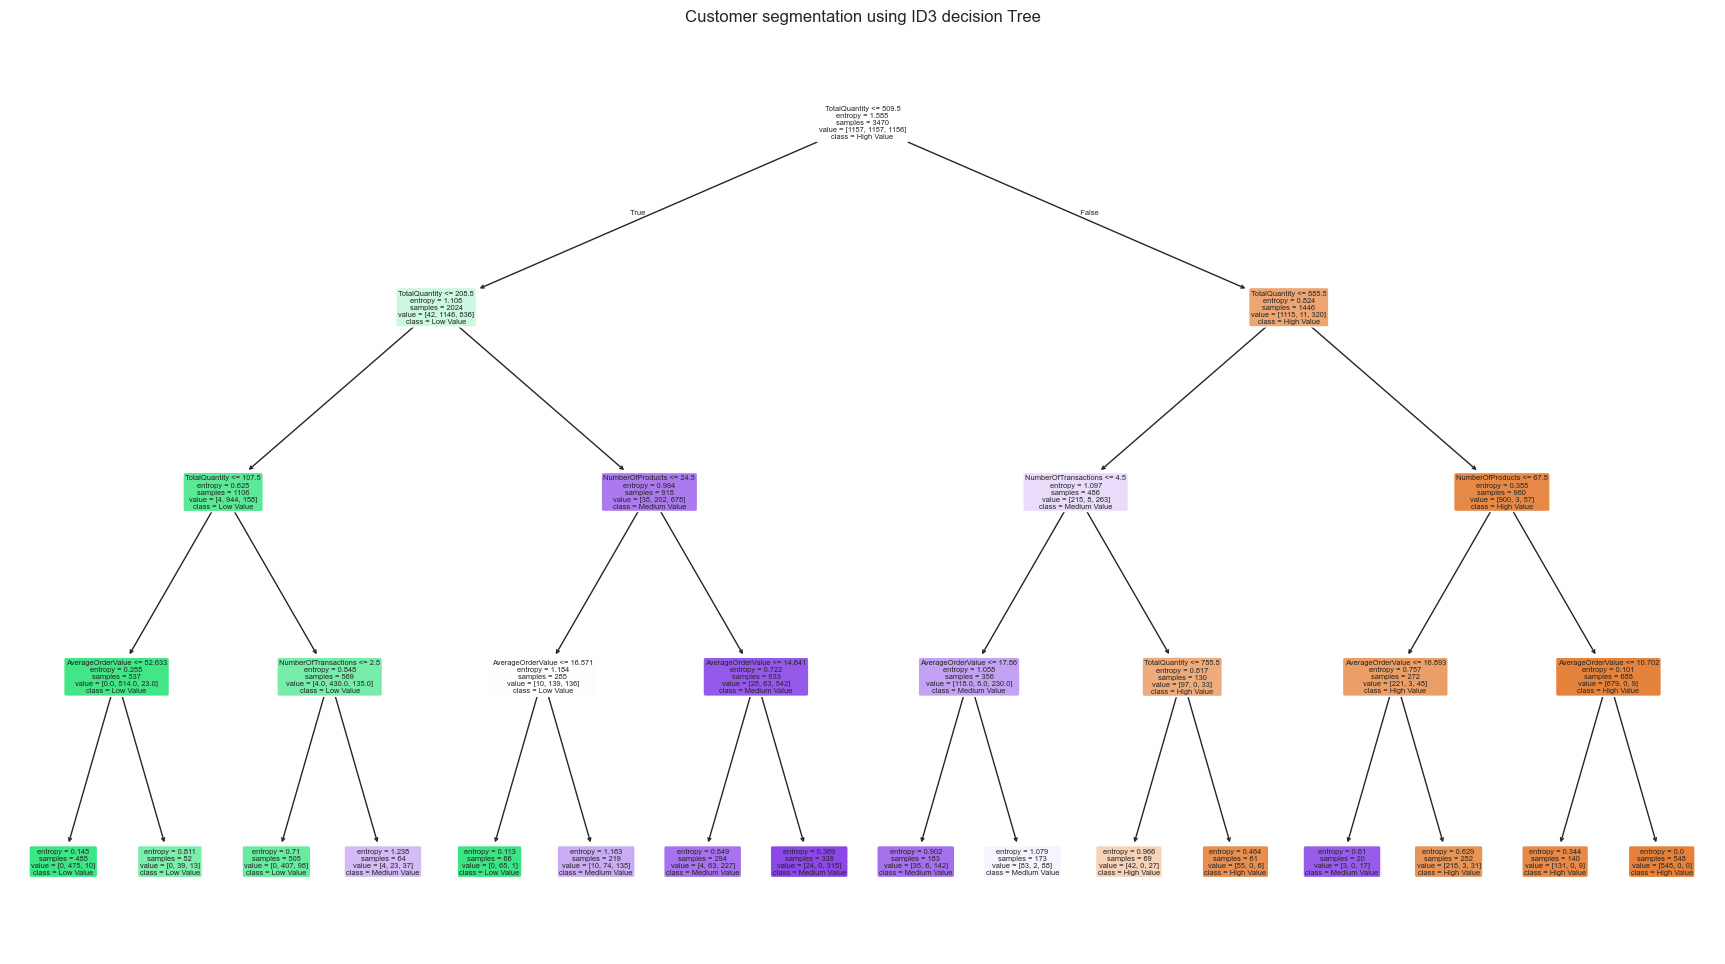

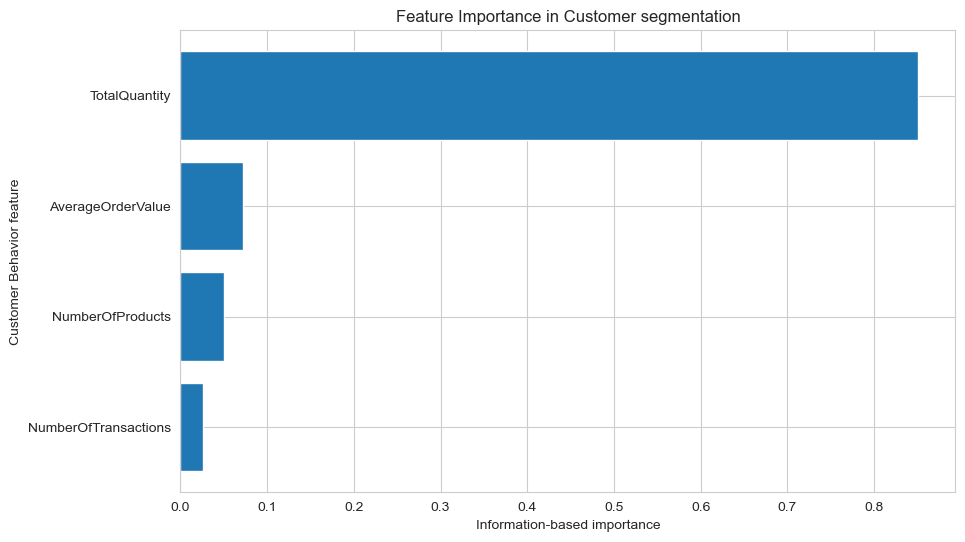

In [55]:
importance=pd.DataFrame({
    "Feature":features,
    "Importance": id3_model.feature_importances_
})

importance_sorted=importance.sort_values(
    "Importance",
    ascending=True
)
plt.figure(figsize=(22,12))

plot_tree(
    id3_model,
    feature_names=features,
    class_names=id3_model.classes_,
    filled=True,
    rounded=True,
    proportion=False
)

plt.title("Customer segmentation using ID3 decision Tree")
plt.show()

plt.figure(figsize=(10,6))

importance_sorted=importance.sort_values(
    "Importance",
    ascending=True
)
plt.barh(
    importance_sorted["Feature"],
    importance_sorted["Importance"]
)

plt.xlabel("Information-based importance")
plt.ylabel("Customer Behavior feature")
plt.title("Feature Importance in Customer segmentation")

plt.show()

        
    

In [2]:
# import pandas as pd

# df = pd.read_excel(
#     r"C:\Users\CSEC2\Downloads\Online Retail.xlsx"
# )

# print("Dataset shape:", df.shape)
# df.head()


Dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# print("Dataset shape:", df.shape)

# print("\nColumn names:")
# print(df.columns.tolist())

# print("\nFirst 5 rows:")
# display(df.head())



Dataset shape: (541909, 8)

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
# print("Data types:")
# print(df.dtypes)

# print("\nMissing values:")
# print(df.isnull().sum())

# print("\nDuplicate rows:")
# print(df.duplicated().sum())


Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate rows:
5268


In [6]:
# # Remove duplicate rows
# df = df.drop_duplicates()

# # Remove rows where CustomerID is missing
# df = df.dropna(subset=["CustomerID"])

# # Remove cancelled invoices
# df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# # Keep only positive quantities
# df = df[df["Quantity"] > 0]

# # Keep only positive prices
# df = df[df["UnitPrice"] > 0]

# print("Dataset shape after cleaning:", df.shape)


Dataset shape after cleaning: (392692, 8)


In [7]:
# df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# print(df["InvoiceDate"].min())
# print(df["InvoiceDate"].max())


2010-12-01 08:26:00
2011-12-09 12:50:00


In [8]:
# df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

# display(
#     df[
#         ["Quantity", "UnitPrice", "TotalAmount"]
#     ].head()
# )


,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [9]:
# customer_df = df.groupby("CustomerID").agg(
#     TotalSpend=("TotalAmount", "sum"),
#     TotalQuantity=("Quantity", "sum"),
#     NumTransactions=("InvoiceNo", "nunique"),
#     NumProducts=("StockCode", "nunique"),
#     AvgTransactionValue=("TotalAmount", "mean")
# ).reset_index()

# display(customer_df.head())


,CustomerID,TotalSpend,TotalQuantity,NumTransactions,NumProducts,AvgTransactionValue
0,12346.0,77183.60,74215,1,1,77183.600000
1,12347.0,4310.00,2458,7,103,23.681319
2,12348.0,1797.24,2341,4,22,57.975484
3,12349.0,1757.55,631,1,73,24.076027
4,12350.0,334.40,197,1,17,19.670588


In [10]:
# date_range_months = (
#     (df["InvoiceDate"].max() - df["InvoiceDate"].min()).days / 30
# )

# if date_range_months == 0:
#     date_range_months = 1

# customer_df["PurchaseFrequency"] = (
#     customer_df["NumTransactions"] / date_range_months
# )

# display(customer_df.head())


,CustomerID,TotalSpend,TotalQuantity,NumTransactions,NumProducts,AvgTransactionValue,PurchaseFrequency
0,12346.0,77183.60,74215,1,1,77183.600000,0.080429
1,12347.0,4310.00,2458,7,103,23.681319,0.563003
2,12348.0,1797.24,2341,4,22,57.975484,0.321716
3,12349.0,1757.55,631,1,73,24.076027,0.080429
4,12350.0,334.40,197,1,17,19.670588,0.080429
